# Предсказание оттока клиентов банка - Modeling & Evaluation (Bagging)

## 1. Описание задачи
#### **Цель ноутбука:**  
Обучить и оценить модели машинного обучения для предсказания оттока клиентов на основе подготовленного датасета.

В рамках этого этапа:
- выполняется разделение данных на train/test
- обучается baseline модель (Logistic Regression, Random forrest)
- подбираются гиперпараметры и оптимальный порог для обученной модели (Random forrest)
- рассчитываются ключевые метрики
- проводится анализ качества модели

## 2. Импорт библиотек

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, make_scorer, fbeta_score, PrecisionRecallDisplay
from sklearn.model_selection import GridSearchCV

## 3. Загрузка данных

In [5]:
df = pd.read_csv("../data/processed_data.csv")

display("Размер:", df.shape)
df.head()

'Размер:'

(10000, 17)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,1,42,2,0.00,1,1,1,101348.88,1,2,464,False,False,False,False,False
1,608,1,41,1,83807.86,1,0,1,112542.58,0,3,456,False,True,False,False,False
2,502,1,42,8,159660.80,3,1,0,113931.57,1,3,377,False,False,False,False,False
3,699,1,39,1,0.00,2,0,0,93826.63,0,5,350,False,False,True,False,False
4,850,1,43,2,125510.82,1,1,1,79084.10,0,5,425,False,True,True,False,False


Далее данные делятся на два массива:  
X — все признаки для обучения модели  
y — целевая переменная `Exited` (0 — клиент остался, 1 — клиент ушёл)

In [6]:
X = df.drop("Exited", axis=1)
y = df["Exited"]
display(y.head(10))
display(X.head())

0    1
1    0
2    1
3    0
4    0
5    1
6    0
7    1
8    0
9    0
Name: Exited, dtype: int64

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,1,42,2,0.00,1,1,1,101348.88,2,464,False,False,False,False,False
1,608,1,41,1,83807.86,1,0,1,112542.58,3,456,False,True,False,False,False
2,502,1,42,8,159660.80,3,1,0,113931.57,3,377,False,False,False,False,False
3,699,1,39,1,0.00,2,0,0,93826.63,5,350,False,False,True,False,False
4,850,1,43,2,125510.82,1,1,1,79084.10,5,425,False,True,True,False,False


В этом блоке мы разделяем данные на три выборки:
- Train — для обучения модели (60% данных)
- Validation — для подбора гиперпараметра C и промежуточной оценки модели (20%)
- Test — для финальной оценки модели на «невидимых» данных (20%)

`stratify=y` сохраняет пропорцию ушедших и оставшихся клиентов в каждой выборке, а `random_state=42` обеспечивает воспроизводимость разбиения. В конце выводим размеры выборок и распределение классов, чтобы убедиться, что данные разделены корректно

In [7]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

print("\nРаспределение тренировочной выборки:")
print(y_train.value_counts(normalize=True))
print("\nРаспределение валидацонной выборки:")
print(y_val.value_counts(normalize=True))
print("\nРаспределениетестовой выборки:")
print(y_test.value_counts(normalize=True))

Train: (6000, 16), Validation: (2000, 16), Test: (2000, 16)

Распределение тренировочной выборки:
Exited
0    0.796167
1    0.203833
Name: proportion, dtype: float64

Распределение валидацонной выборки:
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64

Распределениетестовой выборки:
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


## 4. Обучение baseline Logistic Regression

В рамках построения baseline-модели была протестирована логистическая регрессия с различными вариантами регуляризации.

1. L1-регуляризация (Lasso)
Первая попытка включала использование L1-регуляризации, которая обнуляет неинформативные признаки и выполняет встроенный отбор признаков.
Однако результаты показали, что модель практически не предсказывает класс «ушёл»:
Recall был близок к нулю
F2-score = 0
Модель фактически предсказывала только доминирующий класс - L1 оказалась слишком агрессивной для наших данных - слабые, но полезные признаки были занулены.

3. ElasticNet (комбинация L1 и L2)  
Далее была протестирована смешанная регуляризация (ElasticNet), сочетающая:  
L1 — для отбора признаков  
L2 — для стабилизации коэффициентов и сохранения слабого сигнала  
Также использовался параметр `class_weight='balanced'` для компенсации дисбаланса классов.

Результаты улучшились:  
Recall для класса «ушёл» вырос  
F2-score = 0.359  
ROC-AUC = 0.60  

Модель начала корректно выделять часть ушедших клиентов, однако дальнейший подбор гиперпараметров (C и l1_ratio) практически не повлиял на качество — метрики оставались стабильными.
Логистическая регрессия (даже с ElasticNet) достигла своего потолка качества на текущем наборе признаков.
Таким образом, для дальнейшего улучшения качества модели целесообразно перейти к нелинейным алгоритмам (например, Random Forest или Gradient Boosting), которые способны учитывать сложные взаимодействия признаков.

In [8]:
baseline_model = LogisticRegression(  
    solver='saga',  
    l1_ratio=0.5,  
    C=1.0,  
    class_weight='balanced',  
    max_iter=10000,  
    random_state=42  
)  
baseline_model.fit(X_train, y_train)  
  
y_val_pred = baseline_model.predict(X_val)  
y_val_prob = baseline_model.predict_proba(X_val)[:, 1]  
  
accuracy = accuracy_score(y_val, y_val_pred)  
precision = precision_score(y_val, y_val_pred)  
recall = recall_score(y_val, y_val_pred)  
f2 = fbeta_score(y_val, y_val_pred, beta=2)  
roc_auc = roc_auc_score(y_val, y_val_prob)  
cm = confusion_matrix(y_val, y_val_pred)  
  
print("Метрики на валидации:")  
print(f"Accuracy: {accuracy:.3f}")  
print(f"Precision: {precision:.3f}")  
print(f"Recall: {recall:.3f}")  
print(f"F2-score: {f2:.3f}")  
print(f"ROC-AUC: {roc_auc:.3f}")  
print("\nConfusion Matrix:")  
print(cm)

Метрики на валидации:
Accuracy: 0.525
Precision: 0.247
Recall: 0.654
F2-score: 0.492
ROC-AUC: 0.601

Confusion Matrix:
[[784 809]
 [141 266]]


### Интерпретация результатов:
- Accuracy = 0.525 - невысокая, но это ожидаемо при дисбалансе классов (класс «ушёл» редкий)
- Precision = 0.247 - из всех предсказанных «ушёл» только ~25% оказались верными
- Recall = 0.654 - модель поймала 65% реально ушедших клиентов → это важно для бизнеса
- F2-score = 0.492 - модифицированное гармоническое среднее, которое придает Recall в два раза больше веса, чем Precision
- ROC-AUC = 0.601 - модель чуть лучше случайной, но ещё есть куда расти

Confusion Matrix:
- 784 - правильно предсказали «остался»
- 809 - ошибочно классифицированы как «ушёл»
- 141 - ушедших не поймали
- 266 - правильно предсказали «ушёл»

## 5. Обучение baseline Random forrest

In [9]:
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)

y_val_pred = rf_baseline.predict(X_val)
y_val_prob = rf_baseline.predict_proba(X_val)[:, 1]

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred, zero_division=0)
recall = recall_score(y_val, y_val_pred)
f2 = fbeta_score(y_val, y_val_pred, beta = 2)
roc_auc = roc_auc_score(y_val, y_val_prob)

print("Метрики на валидации:")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F2-score:  {f2:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Метрики на валидации:
Accuracy:  0.865
Precision: 0.762
Recall:    0.486
F2-score:  0.524
ROC-AUC:   0.850

Confusion Matrix:
[[1531   62]
 [ 209  198]]


## Интерпретация результатов:
- Accuracy = 0.865 — высокая, модель хорошо классифицирует большинство клиентов. Однако при дисбалансе классов эта метрика не является ключевой.
- Precision = 0.762 — из всех клиентов, которых модель предсказала как «ушёл», 76% действительно ушли. Это означает низкое количество ложных тревог — модель достаточно точная.
- Recall = 0.486 — модель обнаруживает примерно 49% реально ушедших клиентов. Почти половину мы всё ещё теряем, но это заметно лучше линейной модели.
- F2-score = 0.524 — комбинированная оценка Precision и Recall. Существенный рост по сравнению с логистической регрессией (0.359 < 0.524).
- ROC-AUC = 0.850 — очень хороший результат. Модель качественно разделяет классы и хорошо ранжирует клиентов по вероятности ухода.

Confusion Matrix:
- 1531 — правильно предсказали «остался»
- 62 — ошибочно классифицированы как «ушёл»
- 209 — ушедших клиентов не поймали
- 198 — правильно предсказали «ушёл»

Общий вывод:
Random Forest значительно превосходит логистическую регрессию.
Модель хорошо контролирует ложные срабатывания (высокий Precision), но всё ещё пропускает часть ушедших клиентов (Recall < 0.5).
Так как ROC-AUC высокий (0.85), есть потенциал увеличить Recall и F1 за счёт подбора порога классификации без изменения самой модели.

## 6.Подбор гиперпараметров `max_depth`, `min_samples_leaf`, `n_estimators` на Validation

Для подбора были выбраны параметры с наибольшим влиянием на качество модели:
- `n_estimators` — количество деревьев, влияющее на стабильность предсказаний
- `max_depth` — максимальная глубина деревьев, контролирующая сложность модели
- `min_samples_leaf` — минимальное количество объектов в листе, помогающее регулировать переобучение

In [10]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

f2_score = make_scorer(fbeta_score, beta=2)

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 5, 10]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=f2_score,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:")
print(grid_search.best_params_)

print("\nЛучший F2 (cv):")
print(round(grid_search.best_score_, 3))


best_rf = grid_search.best_estimator_

y_val_pred = best_rf.predict(X_val)
y_val_prob = best_rf.predict_proba(X_val)[:, 1]

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred, zero_division=0)
recall = recall_score(y_val, y_val_pred)
f2 = fbeta_score(y_val, y_val_pred, beta = 2)
roc_auc = roc_auc_score(y_val, y_val_prob)

print("\nМетрики на валидации:")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F2-score:  {f2:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Лучшие параметры:
{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}

Лучший F2 (cv):
0.485

Метрики на валидации:
Accuracy:  0.865
Precision: 0.762
Recall:    0.486
F2-score:  0.524
ROC-AUC:   0.850

Confusion Matrix:
[[1531   62]
 [ 209  198]]


Результат: лучшая комбинация параметров оказалась почти такой же, как baseline:  
`{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}`  
Это говорит о том, что baseline Random Forest уже был близок к оптимальному, и гиперпараметры F2 не улучшили В данной задаче Random Forest уже хорошо справляется с нелинейными зависимостями, поэтому основной прирост качества будет достигаться не через гиперпараметры, а через оптимизацию порога классификации и работу с признаками.

## 7. Подбор оптимального порога

В этом блоке подбирался оптимальный порог классификации для Random Forest, чтобы увеличить F2-score на классе «ушёл». По умолчанию модель использует порог 0.5, что для дисбалансных задач часто даёт низкий Recall.
Я перебрал пороги от 0.1 до 0.9 и для каждого посчитали F2-score на validation.

Лучший порог: 0.16
F2-score при этом пороге: 0.690

Метрики на валидации с оптимальным порогом:
Accuracy:  0.698
Precision: 0.390
Recall:    0.855
F2-score:  0.690
ROC-AUC:   0.850

Confusion Matrix:
[[1048  545]
 [  59  348]]


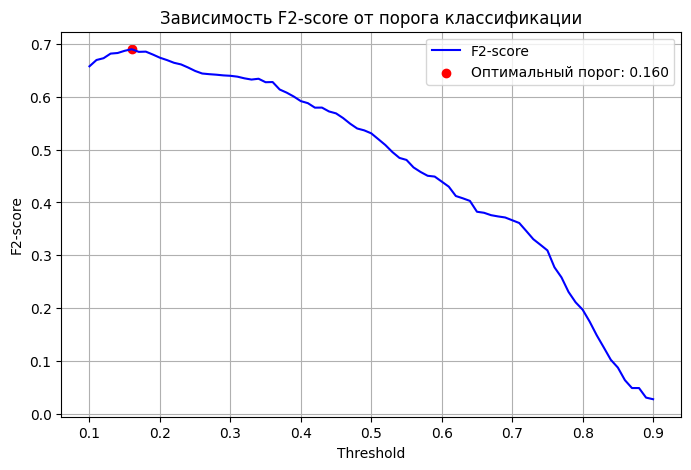

In [22]:
y_probs = best_rf.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.01)
f2_scores = []

for t in thresholds:
    y_pred_thresh = (y_probs >= t).astype(int)
    f2_scores.append(fbeta_score(y_val, y_pred_thresh, beta=2))

best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

print(f"Лучший порог: {best_threshold:.2f}")
print(f"F2-score при этом пороге: {best_f2:.3f}")

y_val_pred_opt = (y_probs >= best_threshold).astype(int)

accuracy = accuracy_score(y_val, y_val_pred_opt)
precision = precision_score(y_val, y_val_pred_opt, zero_division=0)
recall = recall_score(y_val, y_val_pred_opt)
roc_auc = roc_auc_score(y_val, y_probs)

print("\nМетрики на валидации с оптимальным порогом:")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F2-score:  {best_f2:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_opt))

plt.figure(figsize=(8,5))
plt.plot(thresholds, f2_scores, label='F2-score', color='blue')
plt.scatter(best_threshold, best_f2, color='red', label=f'Оптимальный порог: {best_threshold:.3f}')
plt.title('Зависимость F2-score от порога классификации')
plt.xlabel('Threshold')
plt.ylabel('F2-score')
plt.legend()
plt.grid(True)
plt.show()

- F2-score вырос с 0.524 до 0.690
- Recall увеличился с 0.486 до 0.855, что важно для бизнеса, который хочет выявлять ушедших клиентов
- Precision  снизился с 0.762 до 0.390, так как увеличилось количество ложных срабатываний
- ROC-AUC осталась стабильной (0.850), так как порог не влияет на способность модели правильно ранжировать клиентов по вероятности ухода
- 
В силу того, что скорее всего банк заинтересован в предотвращении оттока клиентов, нежели в строгой экономии на них, можно считать, что снижение Precision при повышении Recall - оптимальный результат

## 8. Оценка модели на test

In [15]:
y_test_probs = best_rf.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_probs >= best_threshold).astype(int)

accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred, zero_division=0)
recall_test = recall_score(y_test, y_test_pred)
f2_test = fbeta_score(y_test, y_test_pred, beta = 2)
roc_auc_test = roc_auc_score(y_test, y_test_probs)

print("Тестовые метрики:")
print(f"Accuracy:  {accuracy_test:.3f}")
print(f"Precision: {precision_test:.3f}")
print(f"Recall:    {recall_test:.3f}")
print(f"F2-score:  {f2_test:.3f}")
print(f"ROC-AUC:   {roc_auc_test:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Тестовые метрики:
Accuracy:  0.697
Precision: 0.388
Recall:    0.843
F2-score:  0.683
ROC-AUC:   0.860

Confusion Matrix:
[[1049  543]
 [  64  344]]


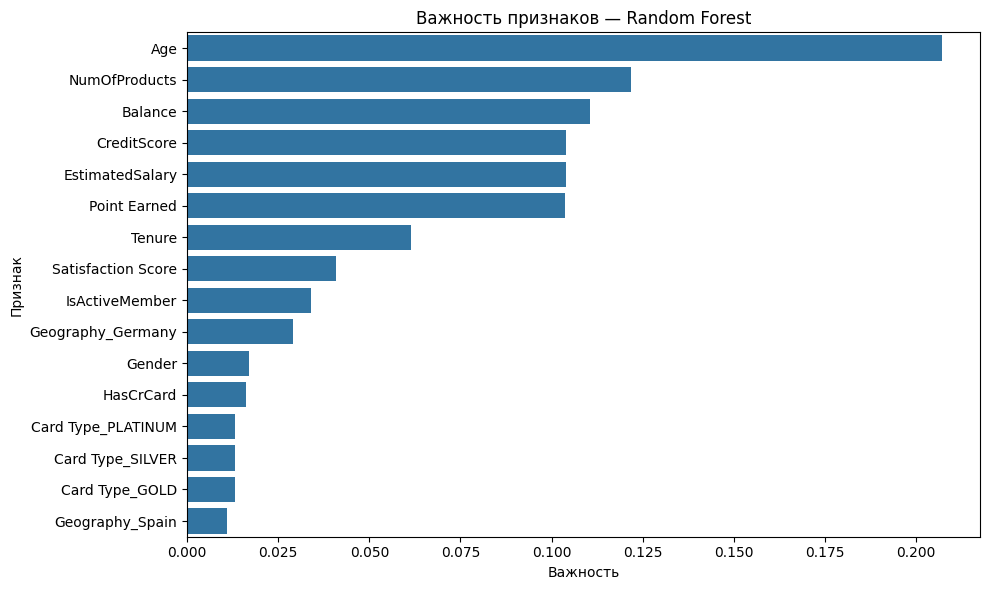

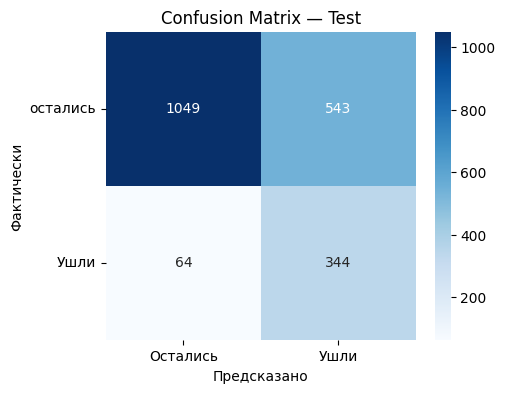

In [16]:
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values(by='importance', ascending=False)

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importances)
plt.title("Важность признаков — Random Forest")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Test")
plt.xlabel("Предсказано")
plt.ylabel("Фактически")
plt.xticks([0.5, 1.5], ["Остались", "Ушли"])
plt.yticks([0.5, 1.5], ["остались", "Ушли"], rotation=0)
plt.show()

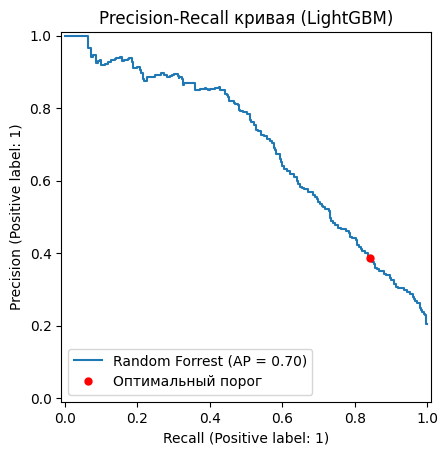

In [20]:
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_probs,
    name="Random Forrest",
    plot_chance_level=False
)

p_point = precision_score(y_test, y_test_pred)
r_point = recall_score(y_test, y_test_pred)

plt.title("Precision-Recall кривая (LightGBM)")

display.ax_.plot(r_point, p_point, 'ro', markersize=5, label="Оптимальный порог")

plt.legend()
plt.show()

Random Forest с оптимальным порогом показывает стабильные результаты на тесте.  
F2 и Recall значительно улучшились по сравнению с baseline логистической регрессии, что важно для бизнеса.  
Precision снизился, но это приемлемый компромисс ради роста Recall.  
Ложные тревоги (FP) немного увеличились, что ожидаемо при пороге 0.16  
Пропущенные ушедшие (FN) уменьшились, модель эффективнее ловит ушедших клиентов

## 9. Сохранение модели, отдельных параметров и метрик

In [ ]:
metrics = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f2": best_f2,
    "roc_auc": roc_auc
}

joblib.dump(best_rf, "../models/random_forest_final_model.pkl")
joblib.dump(best_threshold, "../models/rf_optimal_threshold.pkl")
joblib.dump(metrics, "../models/rf_validation_metrics.pkl")

# Random Forest — Финальный результат

## Этапы работы
1. Подготовка данных: разделение на X (признаки) и y (целевая переменная "Exited"), train/validation с заданным random_state.
2. Построение baseline Random Forest:
   - 200 деревьев, max_depth=None, min_samples_leaf=1
   - F2 = 0.524, ROC-AUC = 0.850
3. Подбор гиперпараметров:
   - GridSearchCV по n_estimators, max_depth, min_samples_leaf
   - Лучшие параметры совпали с baseline (почти нет прироста)
4. Оптимизация порога классификации:
   - Подбор порога от 0.1 до 0.9 по F2
   - Оптимальный порог = 0.16, F2 = 0.683
   - Recall вырос с 0.486 до 0.843, Precision снизился с 0.762 до 0.388

## Итоговые метрики
| Метрика  | Baseline RF | RF validation + порог 0.16 | RF test + порог 0.16 |
|----------|------------|----------------|----------------|
| Accuracy | 0.865      | 0.845          | 0.846          |
| Precision| 0.762      | 0.390          | 0.388          |
| Recall   | 0.486      | 0.855          | 0.843          |
| F2-score | 0.524      | 0.690          | 0.685          |
| ROC-AUC  | 0.850      | 0.850          | 0.860          |


## Confusion Matrix (тесты)
[[1049  543]  
 [  64  344]]

## Выводы
- Random Forest значительно превосходит логистическую регрессию в данной задаче.
- Основное улучшение метрик достигнуто за счёт оптимизации порога.

Для дальнейшего повышения качества можно:
  - Создавать новые признаки и трансформировать существующие (feature engineering)
  - Балансировать классы (SMOTE, undersampling)
  - Использовать более сложные модели, например градиентный бустинг, который будет рассмотрен в следующем ноутбуке.